In [1]:
import os

os.environ["TF_ENABLE_ONEDNN_OPTS"]="0"

import numpy as np
import tensorflow as tf
from tabulate import tabulate
from tensorflow.python.client import device_lib
from tqdm import tqdm
import time

from tensorflow.keras import mixed_precision

# tf.keras.mixed_precision.set_global_policy('mixed_float16')

# tf.config.optimizer.set_jit(False)


2025-10-25 04:32:29.925321: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761346950.018870 1791765 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761346950.043762 1791765 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761346950.265248 1791765 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761346950.265274 1791765 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761346950.265275 1791765 computation_placer.cc:177] computation placer alr

In [2]:

def print_gpu_details():
    """Prints all available GPUs in a formatted table with key details"""
    # Get list of all devices
    devices = device_lib.list_local_devices()
    gpu_details = []
    
    for device in devices:
        if device.device_type == 'GPU':
            # Extract details from the device description string
            desc = device.physical_device_desc
            details = {
                'Device ID': device.name.split(':')[-1],
                'Name': desc.split('name: ')[1].split(',')[0] if 'name: ' in desc else 'Unknown',
                'Memory (GB)': f"{device.memory_limit / (1024**3):.2f}",
                'PCI Bus ID': desc.split('pci bus id: ')[1].split(',')[0] if 'pci bus id: ' in desc else 'Unknown',
                'GFX Version': os.environ.get('HSA_OVERRIDE_GFX_VERSION', 'Native')
            }
            gpu_details.append(details)
    
    # Print table if GPUs found
    if gpu_details:
        print("\n" + "="*85)
        print("ACTIVE GPU CONFIGURATION".center(85))
        print("="*85)
        print(tabulate(gpu_details, headers="keys", tablefmt="grid"))
        print("="*85+ "\n")
    else:
        print("No GPU devices found!")


def configure_gpu(vram_limit):
    """Configure GPU settings with optional GFX override"""
    
    # Verify GPU availability
    gpus = tf.config.list_physical_devices('GPU')
    
    if gpus:
        try:
            # Limit VRAM on the specified GPU
            
            for gid in range(len(gpus)):
                
                tf.config.experimental.set_virtual_device_configuration(
                    gpus[gid],
                    [tf.config.experimental.VirtualDeviceConfiguration(
                        memory_limit=vram_limit[gid] * 1024)]  # Convert GB to MB
                )
                print(f"GPU {gid} VRAM limited to {vram_limit[gid]}GB")
                
        except RuntimeError as e:
            print(f"Error setting VRAM limit: {e}")
    
    if not gpus:
        raise RuntimeError(f"No GPU found")
    
    for gid in range(len(gpus)):
        print(f"Configured GPU {gid}: {tf.config.experimental.get_device_details(gpus[gid])}") 
        
        with tf.device('/GPU:'+str(gid)):  # Force GPU usage
            x = tf.ones((1, 1))    # Smallest possible tensor
            y = x + 1              # Simple operation
            y.numpy()              # Force execution

In [3]:
VRAM = [3.55]

configure_gpu(VRAM)

print_gpu_details()

GPU 0 VRAM limited to 3.55GB
Configured GPU 0: {'compute_capability': (8, 6), 'device_name': 'NVIDIA GeForce RTX 3050 Laptop GPU'}

                               ACTIVE GPU CONFIGURATION                              
+-------------+------------------------------------+---------------+--------------+---------------+
|   Device ID | Name                               |   Memory (GB) | PCI Bus ID   | GFX Version   |
+=============+====================================+===============+==============+===============+
|           0 | NVIDIA GeForce RTX 3050 Laptop GPU |          3.55 | 0000:01:00.0 | Native        |
+-------------+------------------------------------+---------------+--------------+---------------+



I0000 00:00:1761346955.641958 1791765 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3635 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1761346955.703106 1791765 gpu_device.cc:2019] Created device /device:GPU:0 with 3635 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [4]:

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models # type: ignore
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence # type: ignore
from tensorflow.keras.callbacks import ModelCheckpoint # type: ignore
from pprint import pprint
# -------------------------
# Constants
# -------------------------

dataset_detail=np.load("/mnt/Extra/Project_Storage/stereo_ML_dataset/org/"+"detail.npy", allow_pickle=True)
dataset_detail=dataset_detail.tolist()

patch_shape = (int(dataset_detail[0]),int(dataset_detail[1]))

target = min(int(dataset_detail[2]*0.8),int(2**18+1))
# target=1000

Dmax = int(dataset_detail[3])
Dmin = int(dataset_detail[4])

resize_fraction = dataset_detail[5]
resize_factor = 1/resize_fraction

feature_dimension =int (dataset_detail[6])

disparity_skip = int(dataset_detail[7])

eff_Dmax = (Dmax-Dmin)//(disparity_skip+1)




In [5]:

org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/"
dataset_org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/train/"
# dataset_org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/train/sampled/"

# -------------------------
# Load memmap datasets
# -------------------------
left_patch_memmap = dataset_org_path + "left_patch.dat"
left_feat_memmap = dataset_org_path + "left_feat.dat"
right_strip_memmap = dataset_org_path + "right_strip.dat"
right_feat_memmap = dataset_org_path + "right_feat.dat"
patch_disparity_memmap = dataset_org_path + "patch_disp.dat"


model_location = org_path+"model/"

left_patches  = np.memmap(left_patch_memmap, dtype=np.float16, mode='r', shape=(target, patch_shape[0], patch_shape[1]))
patch_feat =np.memmap(left_feat_memmap, dtype=np.float16, mode='r', shape=(target, feature_dimension))

right_strips  = np.memmap(right_strip_memmap, dtype=np.float16, mode='r', shape=(target, eff_Dmax, patch_shape[0], patch_shape[1] ))
strip_feat =np.memmap(right_feat_memmap, dtype=np.float16, mode='r', shape=(target,  eff_Dmax, feature_dimension))

median_disp   = np.memmap(patch_disparity_memmap, dtype=np.int16, mode='r', shape=(target,))

default_mask = np.ones((target, eff_Dmax), dtype=np.bool_)



In [6]:
# def data_printer(array):
#     print("Min : ",np.min(array))
#     print("Mean : ",np.mean(array))
#     print("Median : ",np.median(array))
#     print("Max : ",np.max(array))
#     print('\n')
    
# data_printer(left_patches)
# data_printer(patch_feat)
# data_printer(right_strips)
# data_printer(strip_feat)
# data_printer(median_disp)
# data_printer(default_mask)


In [7]:
# -------------------------
# Imports
# -------------------------
import tensorflow as tf
from tensorflow.keras import layers, models
import os


# -------------------------
# Checkpoint callback 
# -------------------------
class Checkpoint(tf.keras.callbacks.Callback):
    def __init__(self, model_location, save_every=4):
        super().__init__()
        self.model_location = model_location
        self.save_every = save_every
        os.makedirs(model_location, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.save_every == 0:
            filename = os.path.join(self.model_location, f"model_epoch_{epoch+1:02d}.keras")
            self.model.save(filename)
            print(f"\n Saved model checkpoint: {filename}\n")


# -------------------------
# GPU Memory Logger
# -------------------------
class GPUMemoryLogger(tf.keras.callbacks.Callback):
    def __init__(self, device_index=0):
        super().__init__()
        self.device_index = device_index

    def on_train_batch_end(self, batch, logs=None):
        try:
            mem_info = tf.config.experimental.get_memory_info(f'GPU:{self.device_index}')
            used = mem_info['current'] / (1024 ** 2)
            peak = mem_info['peak'] / (1024 ** 2)
            print(f"Batch {batch}: GPU{self.device_index} memory used = {used:.1f} MB | peak = {peak:.1f} MB")
        except Exception as e:
            print(f"Could not fetch GPU info: {e}")
            
import subprocess
import re
import tensorflow as tf

# -------------------------
# GPU Utilization Logger
# -------------------------
class GPUUtilizationLogger(tf.keras.callbacks.Callback):
    def __init__(self, device_index=0):
        super().__init__()
        self.device_index = device_index

    def on_train_batch_end(self, batch, logs=None):
        try:
            result = subprocess.run(
                ['nvidia-smi', '--query-gpu=utilization.gpu', '--format=csv,nounits,noheader', '-i', str(self.device_index)],
                stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
            )
            if result.returncode == 0:
                usage = int(result.stdout.strip())
                print(f"Batch {batch}: GPU{self.device_index} utilization = {usage}%")
            else:
                print(f"Batch {batch}: Could not fetch GPU utilization: {result.stderr.strip()}")
        except Exception as e:
            print(f"Could not fetch GPU utilization: {e}")


checkpoint_cb = Checkpoint(model_location, save_every=5)
gpu_logger = GPUMemoryLogger()
gpu_util = GPUUtilizationLogger()


In [8]:

import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split


class StereoBatchGenerator(Sequence):
    def __init__(self, left_memmap, right_memmap, left_feat, right_feat, disp_mask,
                 disp_memmap, disp_skip=0, batch_size=32, indices=None, shuffle=True, **kwargs):
        
        super().__init__(**kwargs)
        self.left = left_memmap
        self.right = right_memmap
        self.feat_l = left_feat
        self.feat_r = right_feat
        self.mask = disp_mask
        self.shuffle = shuffle
        self.batch_size = batch_size
        self.disp = disp_memmap
        self.disp_skip = disp_skip

        # Indices for shuffling
        if indices is None:
            self.indices = np.arange(len(self.left))
        else:
            self.indices = np.array(indices)

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        left_norm = np.expand_dims(self.left[batch_idx], axis=-1).astype('float32')
        right_norm = np.expand_dims(self.right[batch_idx], axis=-1).astype('float32')

        if self.disp_skip > 0:
            step = self.disp_skip + 1
            right_norm = right_norm[:, ::step, ...]      # (B, Dmax/(skip+1), H, W, 1)
            strip_feat = self.feat_r[batch_idx, ::step, :].astype('float32')
            strip_mask = self.mask[batch_idx, ::step]
        else:
            strip_feat = self.feat_r[batch_idx].astype('float32')
            strip_mask = self.mask[batch_idx]

        patch_feat = self.feat_l[batch_idx].astype('float32')

        disp_batch = (self.disp[batch_idx] // (self.disp_skip + 1)).astype('int32')

        return (
            (left_norm, right_norm, patch_feat, strip_feat, strip_mask),
            disp_batch
        )

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


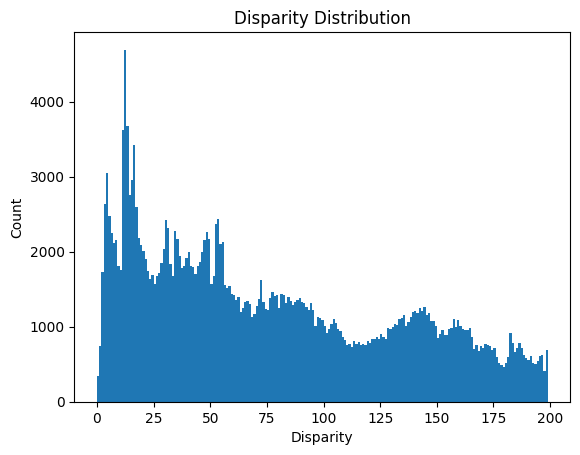

In [9]:

import matplotlib.pyplot as plt
plt.hist(median_disp, bins=np.arange(median_disp.min(), median_disp.max()+1))
plt.title("Disparity Distribution")
plt.xlabel("Disparity")
plt.ylabel("Count")
plt.show()




In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# ------------------------------------------------------------
# Custom Similarity Layer with mask (for inference)
# ------------------------------------------------------------
class SimilarityLayer(layers.Layer):
    def __init__(self, max_d, **kwargs):
        super().__init__(**kwargs)
        self.max_d = max_d

    def call(self, inputs):
        E_left, E_right, mask = inputs
        mask = tf.cast(mask, tf.float32)

        E_left_exp = tf.expand_dims(E_left, axis=1)
        E_left_exp = tf.tile(E_left_exp, [1, self.max_d, 1])

        # Normalize embeddings
        E_left_norm = tf.nn.l2_normalize(E_left_exp, axis=-1, epsilon=1e-6)
        E_right_norm = tf.nn.l2_normalize(E_right, axis=-1, epsilon=1e-6)

        sim = tf.reduce_sum(E_left_norm * E_right_norm, axis=-1)  # (B, max_d)

        # Mask invalid disparities
        sim_masked = sim * mask + (1.0 - mask) * (-1e9)
        return sim_masked

    def compute_output_shape(self, input_shape):
        batch_size = input_shape[0][0]
        return (batch_size, self.max_d)


class ClipLayer(layers.Layer):
    def call(self, inputs):
        return tf.clip_by_value(inputs, 1e-7, 1.0)


# ------------------------------------------------------------
# Model definition
# ------------------------------------------------------------
def create_stereo_model(patch_shape, feature_dim, max_d):
    """
    Stereo model that supports mask-based similarity and contrastive training.
    All embeddings are aligned to filters[2] without reducing patch embeddings.
    """
    filters = [8, 16, 32, 64, 128, 256]  # filters[2] = 256
    filters = filters[2:]

    # -----------------------
    # Inputs
    # -----------------------
    left_patch_input = layers.Input(shape=(*patch_shape, 1), name='left_patch')
    right_patch_input = layers.Input(shape=(max_d, *patch_shape, 1), name='right_patch')
    left_feat_input = layers.Input(shape=(feature_dim,), name='left_feat')
    right_feat_input = layers.Input(shape=(max_d, feature_dim), name='right_feat')
    mask_input = layers.Input(shape=(max_d,), name='mask')

    # -----------------------
    # Left encoder
    # -----------------------
    x = layers.Conv2D(filters[0], 3, activation='relu', padding='same')(left_patch_input)
    x = layers.Conv2D(filters[1], 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    left_patch_emb = layers.Dense(filters[2], activation='relu')(x)  # keep patch embedding at 256

    left_feat_dense = layers.LayerNormalization()(left_feat_input)
    left_feat_dense = layers.Dense(filters[2], activation='relu')(left_feat_dense)  # project features to 256

    alpha_left = tf.Variable(0.5, trainable=True, dtype=tf.float32, name='alpha_left')
    E_left = alpha_left * left_patch_emb + (1.0 - alpha_left) * left_feat_dense

    # -----------------------
    # Shared right encoder
    # -----------------------
    def right_encoder_layer():
        inp = layers.Input(shape=(*patch_shape, 1))
        y = layers.Conv2D(filters[0], 3, activation='relu', padding='same')(inp)
        y = layers.Conv2D(filters[1], 3, activation='relu', padding='same')(y)
        y = layers.GlobalAveragePooling2D()(y)
        y = layers.Dense(filters[2], activation='relu')(y)  # keep right patch embedding at 256
        return models.Model(inp, y)

    patch_encoder = right_encoder_layer()
    
    right_patch_emb = layers.TimeDistributed(patch_encoder)(right_patch_input)

    right_feat_dense = layers.LayerNormalization()(right_feat_input)
    right_feat_dense = layers.TimeDistributed(layers.Dense(filters[2], activation='relu'))(right_feat_dense)  # project to 256

    alpha_right = tf.Variable(0.5, trainable=True, dtype=tf.float32, name='alpha_right')
    E_right = alpha_right * right_patch_emb + (1.0 - alpha_right) * right_feat_dense

    # -----------------------
    # Similarity computation (kept for inference)
    # -----------------------
    sim_layer = SimilarityLayer(max_d)
    sim_masked = sim_layer([E_left, E_right, mask_input])

    out_prob = layers.Softmax(axis=-1, dtype='float32', name='prob_output')(sim_masked)
    out_prob = ClipLayer()(out_prob)

    model = models.Model(
        inputs=(left_patch_input, right_patch_input, left_feat_input, right_feat_input, mask_input),
        outputs=out_prob,
        name='Stereo_Matching_Model'
    )

    return model



# ------------------------------------------------------------
# Off-by-K Metric (optional)
# ------------------------------------------------------------
def off_by_k_metric(k):
    def metric(y_true, y_pred):
        pred_disp = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        off_k = tf.abs(tf.cast(pred_disp, tf.int32) - tf.cast(tf.squeeze(y_true), tf.int32)) <= k
        return tf.reduce_mean(tf.cast(off_k, tf.float32))
    return metric

from tensorflow.keras.optimizers.schedules import CosineDecayRestarts

# ------------------------------------------------------------
# Training function (updated to use contrastive loss)
# ------------------------------------------------------------
def train_stereo_model(model, train_gen, val_gen, epochs=10, lr=1e-3, k=1, weights=None):
    
    early_stop = callbacks.EarlyStopping(
        monitor='val_metric',
        patience=5,
        restore_best_weights=True,
        mode='max'
    )
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=[off_by_k_metric(k)]
    )

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        class_weight=weights,
        callbacks=[early_stop,checkpoint_cb]
    )
    return history


In [11]:
BATCH_SIZE = 16
EPOCHS = 500
DISP_SKIP = 1
# -----------------------------------------------------------
# Usage
# -----------------------------------------------------------

from sklearn.model_selection import train_test_split
from tensorflow.keras import optimizers, callbacks

# -----------------------------------------------------------
# Build generators for image + precomputed features
# -----------------------------------------------------------
all_indices = np.arange(len(left_patches))
idx_train, idx_val = train_test_split(all_indices, test_size=0.1, random_state=42)

train_gen = StereoBatchGenerator(
    left_memmap=left_patches,
    right_memmap=right_strips,
    left_feat=patch_feat,
    right_feat=strip_feat,
    disp_mask = default_mask,
    disp_memmap=median_disp,
    batch_size=BATCH_SIZE,
    indices=idx_train,
    disp_skip=DISP_SKIP,
    shuffle=False
)

val_gen = StereoBatchGenerator(
    left_memmap=left_patches,
    right_memmap=right_strips,
    left_feat=patch_feat,
    right_feat=strip_feat,
    disp_mask = default_mask,
    disp_memmap=median_disp,
    batch_size=BATCH_SIZE,
    indices=idx_val,
    disp_skip=DISP_SKIP,
    shuffle=False
)



model = create_stereo_model(patch_shape=patch_shape, feature_dim=feature_dimension, max_d=(eff_Dmax//(DISP_SKIP+1)))

model.summary()

Model: "Stereo_Matching_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ left_patch          │ (None, 16, 16, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 16,    │        320 │ left_patch[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ left_feat           │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_feat          │ (None, 100, 7)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 7)         │         14 │ left_feat[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_patch         │ (None, 100, 16,   │          0 │ -                 │
│ (InputLayer)        │ 16, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 7)    │         14 │ right_feat[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      1,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 100, 128)  │     27,136 │ right_patch[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 100, 128)  │      1,024 │ layer_normalizat… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 128)       │          0 │ dense_1[0][0]     │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 100, 128)  │          0 │ time_distributed… │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 100, 128)  │          0 │ time_distributed… │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ multiply[0][0], 

 Total params: 56,348 (220.11 KB)

 Trainable params: 56,348 (220.11 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.arange(eff_Dmax)
existing = np.unique(median_disp)
weights_existing = compute_class_weight('balanced', classes=existing, y=median_disp)
weights = {int(c): float(w) for c, w in zip(existing, weights_existing)}

# Fill missing with neutral weight
for c in classes:
    weights.setdefault(int(c), 1.0)


# print("Unique labels:", classes)
# print("Weights:", class_weights)

In [ ]:

k_actual = 3

k_off_value = int(np.ceil((k_actual/(disparity_skip+1))/(DISP_SKIP+1)))
print("K Off Metric :",k_off_value,"\n\n")


history = train_stereo_model(model, train_gen, val_gen, epochs=EPOCHS, lr=1e-3, k= k_off_value, weights=weights)




K Off Metric : 2 


Epoch 1/500


I0000 00:00:1761346965.222309 1791929 service.cc:152] XLA service 0x757434012950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761346965.222327 1791929 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-10-25 04:32:45.619753: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1761346969.787159 1791929 cuda_dnn.cc:529] Loaded cuDNN version 90701
2025-10-25 04:33:17.302985: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion', 480 bytes spill stores, 476 bytes spill loads

I0000 00:00:1761346997.440152 1791929 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 2704/14746 ━━━━━━━━━━━━━━━━━━━━ 4:45 24ms/step - loss: 3.3646 - metric: 0.2542

2025-10-25 04:34:27.626572: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_782', 8 bytes spill stores, 8 bytes spill loads



14746/14746 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 3.3239 - metric: 0.2993

2025-10-25 04:40:23.412612: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_387', 8 bytes spill stores, 8 bytes spill loads



14746/14746 ━━━━━━━━━━━━━━━━━━━━ 469s 29ms/step - loss: 3.3048 - metric: 0.3151 - val_loss: 4.3114 - val_metric: 0.3308
Epoch 2/500
14746/14746 ━━━━━━━━━━━━━━━━━━━━ 445s 30ms/step - loss: 3.2892 - metric: 0.3288 - val_loss: 4.2979 - val_metric: 0.3319
Epoch 3/500
14746/14746 ━━━━━━━━━━━━━━━━━━━━ 374s 25ms/step - loss: 3.2796 - metric: 0.3321 - val_loss: 4.3055 - val_metric: 0.3109
Epoch 4/500
14746/14746 ━━━━━━━━━━━━━━━━━━━━ 380s 26ms/step - loss: 3.2750 - metric: 0.3361 - val_loss: 4.2859 - val_metric: 0.3358
Epoch 5/500
14745/14746 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3.2712 - metric: 0.3360
 Saved model checkpoint: /mnt/Extra/Project_Storage/stereo_ML_dataset/model/model_epoch_05.keras

14746/14746 ━━━━━━━━━━━━━━━━━━━━ 389s 26ms/step - loss: 3.2672 - metric: 0.3383 - val_loss: 4.2930 - val_metric: 0.3242
Epoch 6/500
14746/14746 ━━━━━━━━━━━━━━━━━━━━ 383s 26ms/step - loss: 3.2634 - metric: 0.3362 - val_loss: 4.2744 - val_metric: 0.3395
Epoch 7/500
14746/14746 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
# # ------------------------------
# # Prediction function
# # ------------------------------
# def predict_stereo_model(model, left_batch, right_batch, lfeat_batch, rfeat_batch, mask_batch):
#     """
#     Returns predicted disparities from a batch of inputs.
#     """
#     pred_probs = model.predict([left_batch, right_batch, lfeat_batch, rfeat_batch, mask_batch])
#     pred_disp = np.argmax(pred_probs, axis=-1)
#     return pred_disp


# # 3. Predict on a validation batch
# (left_batch, right_batch, lfeat_batch, rfeat_batch, mask_batch), disp_batch = val_gen[0]
# pred_disp = predict_stereo_model(model, left_batch, right_batch, lfeat_batch, rfeat_batch, mask_batch)

In [ ]:

import numpy as np

# Save
np.save(model_location+"history.npy", history.history)

model.save(model_location+"best_model.keras")
